In [1]:
from dummy_app.models.builder import MVMTSPBuilder 
from dummy_app.designs.envsim import EnvSim
from dummy_app.designs.mobility import GroundUserGroup
from dummy_app.designs.voronoi_map import Map 
from dummy_app.tools.logger import logger 

import os 
import numpy as np 
from pathlib import Path 

In [ ]:
PROJECT_DIR = os.getcwd() 
PROJECT_ASSETS = f"{PROJECT_DIR}/assets"

max_memory = 2 * 1024 *1024 *1024
number_of_agents = 5
max_battery = 1500
constraints = ['const_0', # NOTE: Constraint for many visits
               'const_1', # NOTE: Constraint for entering and leaving depot 
                #  'const_2', # NOTE: Constraint for position on first and last time step
                   'const_3', # NOTE: Constraint for time on depot at first and last time step 
                  #    'const_4', # NOTE: Constraint for ensuring that only 1 travel for depot in/out is allowed 
                  #      'const_5', # NOTE: Constraint to prohibit depot loop 
                         'const_6', # NOTE: Constraint to allow a single travel between nodes 
                  #          'const_7', # NOTE: Constraint to set the busy characteristic on the agent 
                             'const_8', # NOTE: Constraint to prevent overlaps with busy 
                  #              'const_9', # NOTE: Constraint to ensure that the time steps in the beginning and end are alligned with the depot decision journey. 
                                #  'const_10', # NOTE: Synchronization of depots for spatial and time variables
                                  #  'const_11', # NOTE: Constraint to ensure time progression 
                                    #  'const_12', # NOTE: Synchronization between spatial and time variables 
                  #                      'const_13', # NOTE: Energy constraint 
                  #                        'const_14',  # NOTE: Constraint to ensure that energy won't be negative (failure) during travel
                                           'const_15', # NOTE: Constaint to ensure that for a specific time step only a single agent can be on that travel
                                             'const_16', # NOTE: Constraint to ensure that agents have unique paths 
                                               'const_17', # NOTE: Constraint to ensure that there are no loops in the paths i->j->i
                                                #  'const_18', 
                                                  #  'const_19',
                                                    #  'const_20',
                                                      #  'const_21',
]

config = {
    "regionalization":True, 
    "genetic_algorithm": True, 
    "individual_solution": False, 
    "constraints":constraints,
}

dist_path = f"{PROJECT_ASSETS}/env_settings/distance_cost.csv"
energy_path = f"{PROJECT_ASSETS}/env_settings/energy_cost.csv"
areas_path = f"{PROJECT_ASSETS}/env_settings/areas.csv"
customers_path = f"{PROJECT_ASSETS}/env_settings/customers.csv"
gues_path = f"{PROJECT_ASSETS}/env_settings/ground_users.csv"


In [3]:
problem = MVMTSPBuilder(config)

In [4]:
mobility_sim = EnvSim() 

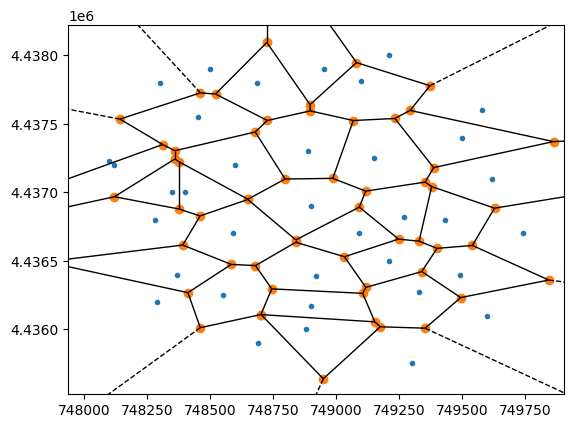

In [5]:
map = Map(data_path=areas_path, incremental=False)
map.voronoi_tessellation()
map.plot_voronoi()


In [6]:
ground_users = GroundUserGroup(
    env=mobility_sim.env, 
    map_obj=map, 
    alpha=0.85, 
    mean_velocity=1.0, 
    sigma=0.5
)

ground_users.load_users(
    data_path=gues_path,
    customers_path=customers_path
)

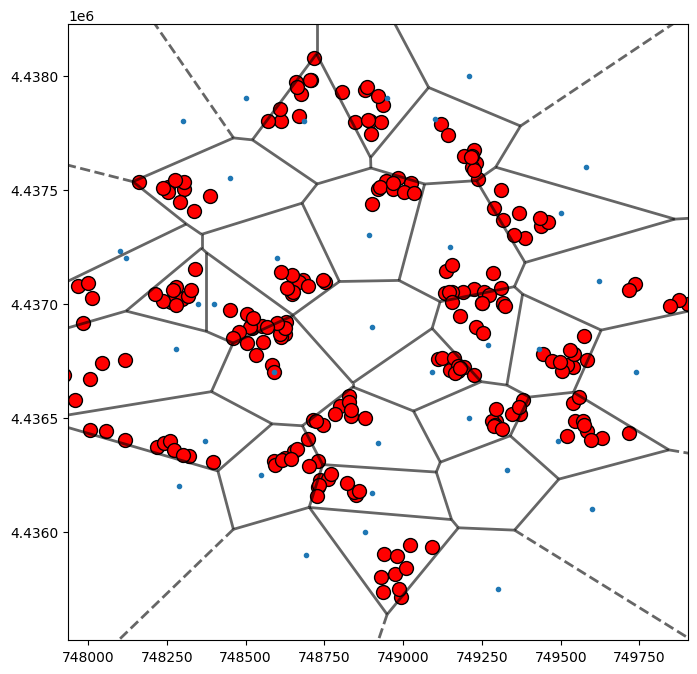

In [7]:
ground_users.plot_users(map.vor_map)

In [8]:
data = problem.preprocess(
    distances_path=dist_path, 
    energies=energy_path, 
    nodes_path=areas_path, 
    agents=number_of_agents, 
    customers_path=customers_path,
    ground_users=gues_path,
    max_battery=max_battery
)

2025-05-12 14:26:56 | INFO | lstm_forecaster | Preprocessing completed successfully...


In [9]:
assignments, updated_clusters =problem.run_model(data, ground_users.group)

Preparing Problem with clustering: 100%|██████████| 8/8 [00:04<00:00,  1.84it/s]

2025-05-12 14:27:01 | INFO | lstm_forecaster | Setting up problem construction completed...
2025-05-12 14:27:01 | INFO | lstm_forecaster | Starting cluster optimization...


In [10]:
# CHECK THAT PULP AND GLPK WORK
# import pulp as pl
# pl.pulpTestAll()

In [11]:
for (cluster_tuple, agents), cluster in zip(assignments.items(), updated_clusters):
    problem.clustering(cluster=cluster, cluster_id=cluster_tuple[0], assignment=agents, depot_id=cluster_tuple[1])
    print(constraints)
    break 

Agent 3 has solution path: [8, 14, 4, 30, 29, 3, 28, 32, 8] with cost: 4.405558125337027
Agent 5 has solution path: [8, 29, 3, 28, 32, 4, 30, 14, 8] with cost: 4.386947301902999
Agent 4 has solution path: [8, 14, 4, 30, 32, 28, 3, 29, 8] with cost: 4.394203993745772
2025-05-12 14:27:02 | INFO | lstm_forecaster | Setting constraints for multi-agent problem...
2025-05-12 14:27:02 | INFO | lstm_forecaster | Constraint | const_8 - Synchronization between time and space | set for cluster. Total constraints: 624
2025-05-12 14:27:02 | INFO | lstm_forecaster | Many-visits multi-agent TSP problem created successfully...
2025-05-12 14:27:02 | INFO | lstm_forecaster | Solving problem for cluster 1...
2025-05-12 14:27:02 | INFO | lstm_forecaster | Set Time Frame is [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
{0: 3, 1: 4, 2: 14, 3: 28, 4: 29, 5: 30, 6: 32, 7: 8}
2025-05-12 14:27:02 | INFO | lstm_forecaster | Memory usage: 256.45 MB
2025-05-12 14:27:02 | INFO | lstm_forecaster | O

In [12]:
problem.paths


{1: [],
 2: [],
 3: [[(8, 32, 1), (32, 14, 2)]],
 4: [[(8, 32, 1), (32, 14, 2), (14, 8, 16)]],
 5: [[(8, 32, 1), (32, 14, 2)]]}

In [13]:
nodes_dict = {0: 3, 1: 4, 2: 14, 3: 28, 4: 29, 5: 30, 6: 32, 7: 8}
V_nodes = list(nodes_dict.keys())

employed_agents = ["Agent_" + str(agent_id) for agent_id in problem.employed_agents]
reverse_dict = {v:k for k,v in nodes_dict.items()}
list_of_agents = {name: int(name.split('_')[-1]) for name in employed_agents}
maxiter_counter = len(V_nodes) * len(problem.timeFrame_per_cluster)
for agent_name, agent_id in list_of_agents.items(): 
    for i in V_nodes: 
        for j in V_nodes: 
            if i != j: 
                for t in problem.timeFrame_per_cluster: 
                    if problem.x[i,j,agent_id].varValue == 1 and problem.t[i,j,agent_id,t].varValue == 1:
                        print(f"x[{i},{j},{agent_id}] = {problem.x[i,j,agent_id].varValue} | t[{i},{j},{agent_id},{t}] = {problem.t[i,j,agent_id,t].varValue} ")

x[3,4,3] = 1 | t[3,4,3,1] = 1 
x[3,4,3] = 1 | t[3,4,3,2] = 1 
x[3,4,3] = 1 | t[3,4,3,3] = 1 
x[3,4,3] = 1 | t[3,4,3,4] = 1 
x[3,4,3] = 1 | t[3,4,3,5] = 1 
x[4,3,3] = 1 | t[4,3,3,1] = 1 
x[4,3,3] = 1 | t[4,3,3,2] = 1 
x[4,3,3] = 1 | t[4,3,3,3] = 1 
x[4,3,3] = 1 | t[4,3,3,4] = 1 
x[4,3,3] = 1 | t[4,3,3,5] = 1 
x[5,7,3] = 1 | t[5,7,3,16] = 1 
x[6,2,3] = 1 | t[6,2,3,1] = 1 
x[6,2,3] = 1 | t[6,2,3,2] = 1 
x[6,2,3] = 1 | t[6,2,3,3] = 1 
x[6,2,3] = 1 | t[6,2,3,4] = 1 
x[6,2,3] = 1 | t[6,2,3,5] = 1 
x[7,6,3] = 1 | t[7,6,3,1] = 1 
x[3,4,5] = 1 | t[3,4,5,1] = 1 
x[3,4,5] = 1 | t[3,4,5,2] = 1 
x[3,4,5] = 1 | t[3,4,5,3] = 1 
x[3,4,5] = 1 | t[3,4,5,4] = 1 
x[3,4,5] = 1 | t[3,4,5,5] = 1 
x[4,3,5] = 1 | t[4,3,5,1] = 1 
x[4,3,5] = 1 | t[4,3,5,2] = 1 
x[4,3,5] = 1 | t[4,3,5,3] = 1 
x[4,3,5] = 1 | t[4,3,5,4] = 1 
x[4,3,5] = 1 | t[4,3,5,5] = 1 
x[5,7,5] = 1 | t[5,7,5,16] = 1 
x[6,2,5] = 1 | t[6,2,5,1] = 1 
x[6,2,5] = 1 | t[6,2,5,2] = 1 
x[6,2,5] = 1 | t[6,2,5,3] = 1 
x[6,2,5] = 1 | t[6,2,5,4] = 1 
x[6,2,

In [14]:
for agent_name, agent_id in list_of_agents.items(): 
    start_node = problem.depots_for_agents[agent_id]
    current_node = reverse_dict[start_node]
    current_time_step = problem.timeFrame_per_cluster[0]

    route = [] 
    iteration = 0 
    steps_required = 0 
    next_node = 0
    while iteration < maxiter_counter: 

        print("Time step ", current_time_step)
        print("current_node", current_node)
        print("Steps Required",steps_required)

        if steps_required > 0:
            # Still in transit → just increase time
            steps_required -= 1
            current_time_step += 1
            iteration += 1
            continue

        if steps_required == 0 and current_time_step != problem.timeFrame_per_cluster[0]: 
            current_node = next_node
        
        found_next_step = False
        for j in V_nodes:
            if j != current_node:
                var_x = problem.x[current_node, j, agent_id]
                var_t = problem.t[current_node, j, agent_id, current_time_step]

                if var_x.varValue == 1 and var_t.varValue == 1:
                    print(f"Time Step {current_time_step}: Agent_{agent_id} moves from {nodes_dict[current_node]} to {nodes_dict[j]}")
                    # Append travel leg (only once)
                    route.append((nodes_dict[current_node], nodes_dict[j], current_time_step))

                    # Setup for the duration of this journey
                    steps_required = problem.tr_times[(current_node, j)] - 1
                    next_node = j
                    found_next_step = True
                    break
        
        if not found_next_step:
              print(f"No next journey found at T={current_time_step} for Agent_{agent_id}. Terminating.")
              break
        
        current_time_step+=1 
        iteration += 1


print(route)


Time step  0
current_node 7
Steps Required 0
No next journey found at T=0 for Agent_3. Terminating.
Time step  0
current_node 7
Steps Required 0
No next journey found at T=0 for Agent_5. Terminating.
Time step  0
current_node 7
Steps Required 0
No next journey found at T=0 for Agent_4. Terminating.
[]


In [15]:
# mobility_sim.simulations(
#     constructor=problem,
#     cues=ground_users, 
#     data=data, 
#     trials=3600
# )